In [3]:
# %% [markdown]
# # Comparison of Balancing Strategies with Hyperparameter Grid Search
# 
# This notebook:
# 1. Splits TCGA into train/val/test (80/16/4? Actually 80% train, 20% test, then inner 80/20 gives 64% train, 16% val, 20% test).
# 2. Balances only the training set using CTGAN and SMOTE‑NC.
# 3. Performs a **grid search** over hyperparameters using the **CTGAN‑balanced** training set and validation set.
# 4. Trains three models (No Balancing, CTGAN, SMOTE) with the best hyperparameters found.
# 5. Evaluates on TCGA test and CGGA with extensive metrics and visualisations.

# %% [markdown]
# ## 1. Imports and Setup

# %%
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random
import copy
import os
from itertools import product

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR

from torch_geometric.data import HeteroData
from torch_geometric.nn import GATv2Conv, Linear

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition

from imblearn.over_sampling import SMOTENC

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

# %% [markdown]
# ## 2. Load Data and Define Feature Columns

# %%
tcga_df = pd.read_csv('../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 
                'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 
                'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']

print("Data loaded.")
print("TCGA shape:", tcga_df.shape)
print("CGGA shape:", cgga_df.shape)

# %% [markdown]
# ## 3. Stratified Splits (80/20 train/test, then inner 80/20 train/val)

# %%
# First split: 80% train, 20% test
train_df, test_df = train_test_split(
    tcga_df, 
    test_size=0.2, 
    stratify=tcga_df['Grade'], 
    random_state=42
)
print("After first split (80% train / 20% test):")
print(f"  Intermediate train size: {len(train_df)}")
print(f"  Test size: {len(test_df)}")
print("  Train class distribution:")
print(train_df['Grade'].value_counts())
print()

# Second split: further split training into final train (80%) and validation (20%)
train_df, val_df = train_test_split(
    train_df, 
    test_size=0.2, 
    stratify=train_df['Grade'], 
    random_state=42
)
print("After inner split (80% of train / 20% of train):")
print(f"  Final train size: {len(train_df)}")
print(f"  Validation size: {len(val_df)}")
print("  Final train class distribution (before balancing):")
print(train_df['Grade'].value_counts())
print()
print(f"Total patients accounted for: {len(train_df) + len(val_df) + len(test_df)} (should equal {len(tcga_df)})")

# %% [markdown]
# ## 4. Create Balanced Training Sets

# %% [markdown]
# ### 4.1 CTGAN Balancing

# %%
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    metadata.update_column(column_name=col, sdtype='categorical')

class_counts = train_df['Grade'].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
samples_needed = class_counts[majority_class] - class_counts[minority_class]

print(f"CTGAN: Generating {samples_needed} synthetic minority samples...")
synthesizer = CTGANSynthesizer(metadata, epochs=150, batch_size=50, verbose=False, cuda=True)
synthesizer.fit(train_df)

condition = Condition(num_rows=samples_needed, column_values={'Grade': minority_class})
synthetic_samples = synthesizer.sample_from_conditions(conditions=[condition])

train_ctgan_df = pd.concat([train_df, synthetic_samples], ignore_index=True)
print("CTGAN-balanced training set created.")
print(train_ctgan_df['Grade'].value_counts())
print()

# %% [markdown]
# ### 4.2 SMOTE‑NC Balancing

# %%
feature_columns = gene_columns + ['Gender', 'Race', 'Age_at_diagnosis']
X_train = train_df[feature_columns]
y_train = train_df['Grade']

categorical_indices = [i for i, col in enumerate(feature_columns) 
                       if col in gene_columns or col in ['Gender', 'Race']]

smote = SMOTENC(categorical_features=categorical_indices, random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X_train, y_train)

train_smote_df = pd.DataFrame(X_res, columns=feature_columns)
train_smote_df['Grade'] = y_res

for col in gene_columns:
    train_smote_df[col] = train_smote_df[col].round().astype(int)

print("SMOTE-balanced training set created.")
print(train_smote_df['Grade'].value_counts())
print()

# %% [markdown]
# ## 5. Graph Construction Function

# %%
def construct_bipartite_heterograph(df):
    graph = HeteroData()
    
    scaler = StandardScaler()
    age_norm = scaler.fit_transform(df[['Age_at_diagnosis']])
    patient_feats = np.hstack([df[['Gender', 'Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(patient_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    
    num_genes = len(gene_columns)
    graph['Gene'].x = torch.eye(num_genes, dtype=torch.float)
    
    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx)
                dst_patients.append(p_idx)
    
    graph['Gene', 'mutates', 'Patient'].edge_index = torch.tensor([src_genes, dst_patients], dtype=torch.long)
    graph['Patient', 'mutated_by', 'Gene'].edge_index = torch.tensor([dst_patients, src_genes], dtype=torch.long)
    
    return graph

# %% [markdown]
# ## 6. Build Graphs (for CTGAN train, val, test, CGGA)

# %%
# We need graphs for CTGAN train (for tuning) and for val/test/CGGA.
tcga_train_ctgan_graph = construct_bipartite_heterograph(train_ctgan_df).to(device)
tcga_val_graph         = construct_bipartite_heterograph(val_df).to(device)
tcga_test_graph        = construct_bipartite_heterograph(test_df).to(device)
cgga_graph             = construct_bipartite_heterograph(cgga_df).to(device)

print("Graphs built for tuning:")
print(f"  CTGAN train: {tcga_train_ctgan_graph['Patient'].x.shape[0]} patients")
print(f"  Val        : {tcga_val_graph['Patient'].x.shape[0]} patients")
print(f"  Test       : {tcga_test_graph['Patient'].x.shape[0]} patients")
print(f"  CGGA       : {cgga_graph['Patient'].x.shape[0]} patients")

# %% [markdown]
# ## 7. Model Definition

# %%
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=8, dropout=0.5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        
        self.patient_lin = Linear(-1, hidden_dim)
        self.gene_lin = Linear(-1, hidden_dim)
        
        self.conv_gene_to_patient = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.conv_patient_to_gene = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        
        self.patient_skip = Linear(hidden_dim, hidden_dim)
        self.gene_skip = Linear(hidden_dim, hidden_dim)
        
        self.classifier = Linear(hidden_dim, out_dim)

    def forward(self, x_dict, edge_index_dict):
        h_patient = F.relu(self.patient_lin(x_dict['Patient']))
        h_gene = F.relu(self.gene_lin(x_dict['Gene']))
        
        out_patient = self.conv_gene_to_patient((h_gene, h_patient), edge_index_dict[('Gene', 'mutates', 'Patient')])
        out_gene = self.conv_patient_to_gene((h_patient, h_gene), edge_index_dict[('Patient', 'mutated_by', 'Gene')])
        
        h_patient = self.patient_skip(h_patient) + out_patient
        h_gene = self.gene_skip(h_gene) + out_gene
        
        h_patient = F.dropout(F.leaky_relu(h_patient, 0.2), self.dropout, training=self.training)
        h_gene = F.dropout(F.leaky_relu(h_gene, 0.2), self.dropout, training=self.training)
        
        return self.classifier(h_patient)

# %% [markdown]
# ## 8. Loss Function and Class Weights

# %%
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Class weights from original imbalanced training set (for loss)
original_counts = train_df['Grade'].value_counts()
majority = original_counts.idxmax()
minority = original_counts.idxmin()
penalty = original_counts[majority] / original_counts[minority]
class_weights = torch.tensor([1.0, penalty], dtype=torch.float).to(device)

criterion = FocalLoss(alpha=1, gamma=2, weight=class_weights)

# %% [markdown]
# ## 9. Training Function (returns best validation AUC and model state)

# %%
def train_model(train_graph, val_graph, params, max_epochs=200, patience=20):
    model = HeteroGATv2(
        hidden_dim=params['hidden_dim'],
        out_dim=2,
        num_heads=params['num_heads'],
        dropout=params['dropout']
    ).to(device)

    with torch.no_grad():
        _ = model(train_graph.x_dict, train_graph.edge_index_dict)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

    best_val_auc = 0
    patience_counter = 0
    best_state = None
    val_aucs = []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        out = model(train_graph.x_dict, train_graph.edge_index_dict)
        loss = criterion(out, train_graph['Patient'].y)
        loss.backward()
        optimizer.step()
        scheduler.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_out = model(val_graph.x_dict, val_graph.edge_index_dict)
            val_probs = F.softmax(val_out, dim=1)[:, 1].cpu().numpy()
            val_labels = val_graph['Patient'].y.cpu().numpy()
            val_auc = roc_auc_score(val_labels, val_probs)
            val_aucs.append(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_val_auc, best_state, val_aucs

Using device: cuda
GPU: NVIDIA GeForce RTX 3050
Data loaded.
TCGA shape: (839, 24)
CGGA shape: (286, 24)
After first split (80% train / 20% test):
  Intermediate train size: 671
  Test size: 168
  Train class distribution:
Grade
0    389
1    282
Name: count, dtype: int64

After inner split (80% of train / 20% of train):
  Final train size: 536
  Validation size: 135
  Final train class distribution (before balancing):
Grade
0    311
1    225
Name: count, dtype: int64

Total patients accounted for: 839 (should equal 839)
CTGAN: Generating 86 synthetic minority samples...


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 601.81it/s]


CTGAN-balanced training set created.
Grade
0    311
1    311
Name: count, dtype: int64

SMOTE-balanced training set created.
Grade
0    311
1    311
Name: count, dtype: int64

Graphs built for tuning:
  CTGAN train: 622 patients
  Val        : 135 patients
  Test       : 168 patients
  CGGA       : 286 patients


Starting grid search with 72 combinations...

Trial 1/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001}
  Validation AUC: 0.9114

Trial 2/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0005}
  Validation AUC: 0.9141

Trial 3/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.005, 'weight_decay': 0.0001}
  Validation AUC: 0.9258

Trial 4/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.005, 'weight_decay': 0.0005}
  Validation AUC: 0.9359

Trial 5/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001}
  Validation AUC: 0.9071

Trial 6/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0005}
  Validation AUC: 0.8938

Trial 7/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.5, 'lr': 0.005, 'weight_decay': 0.0001}
  Validation AUC: 0.9318

Trial 8/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.5, 'lr': 0.0

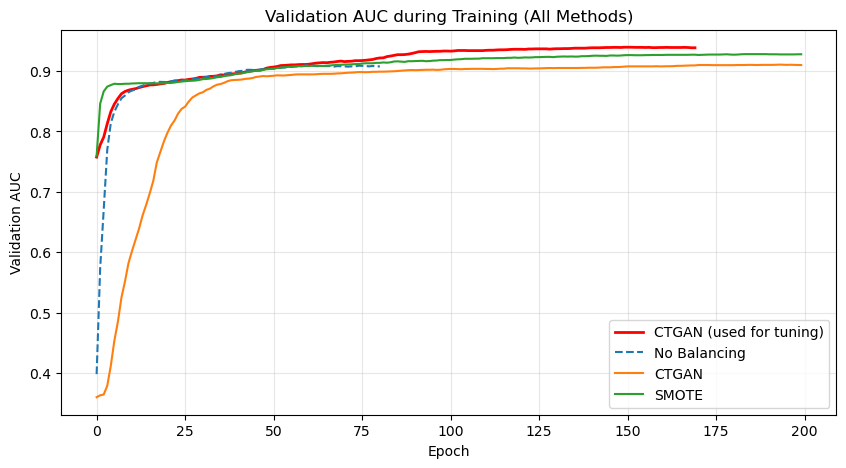

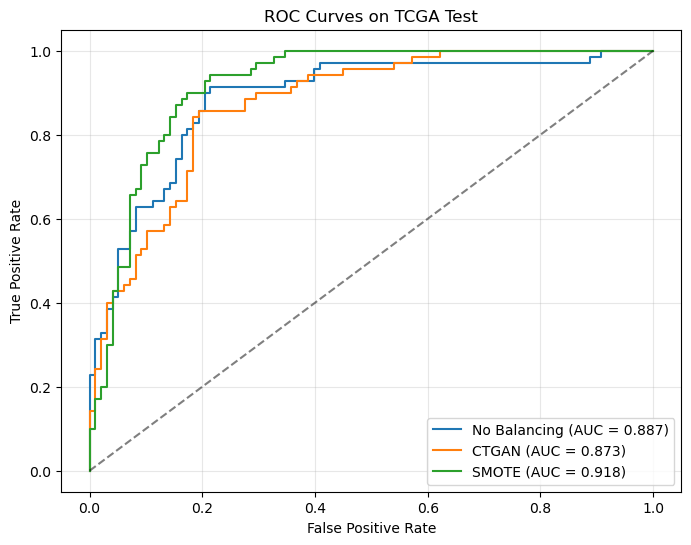

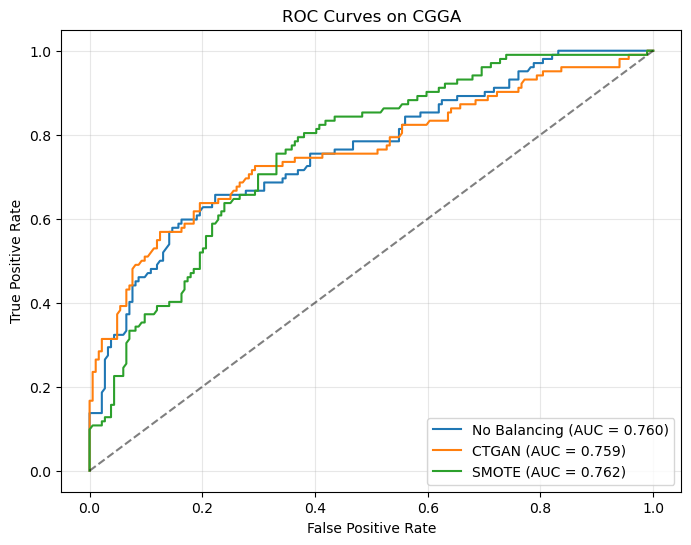

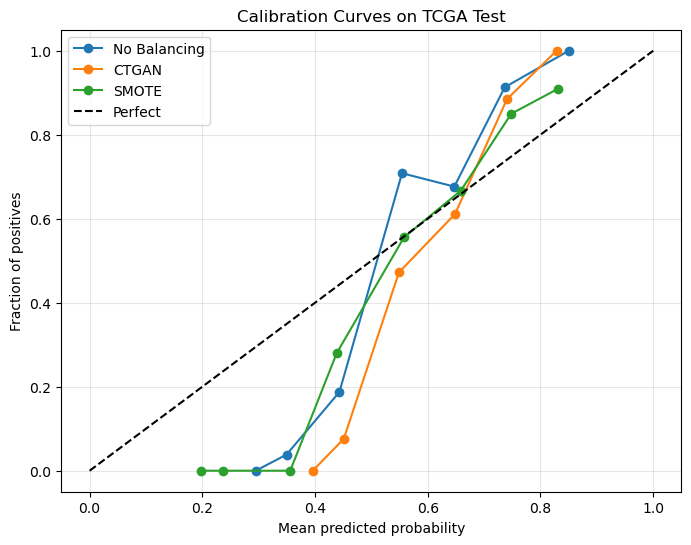

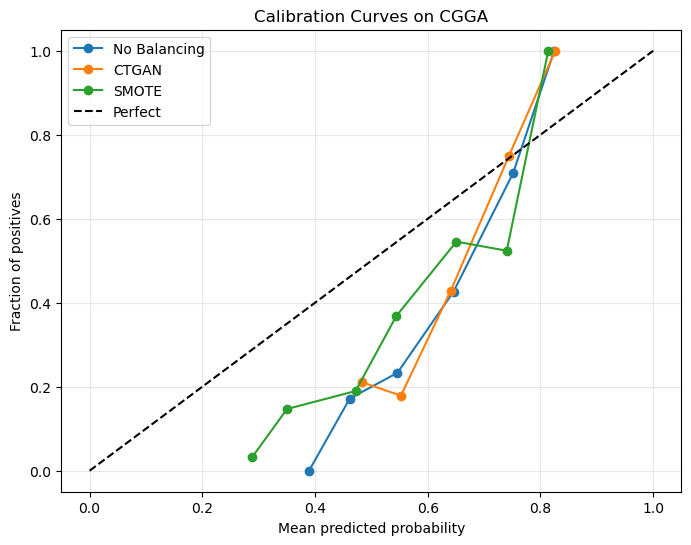

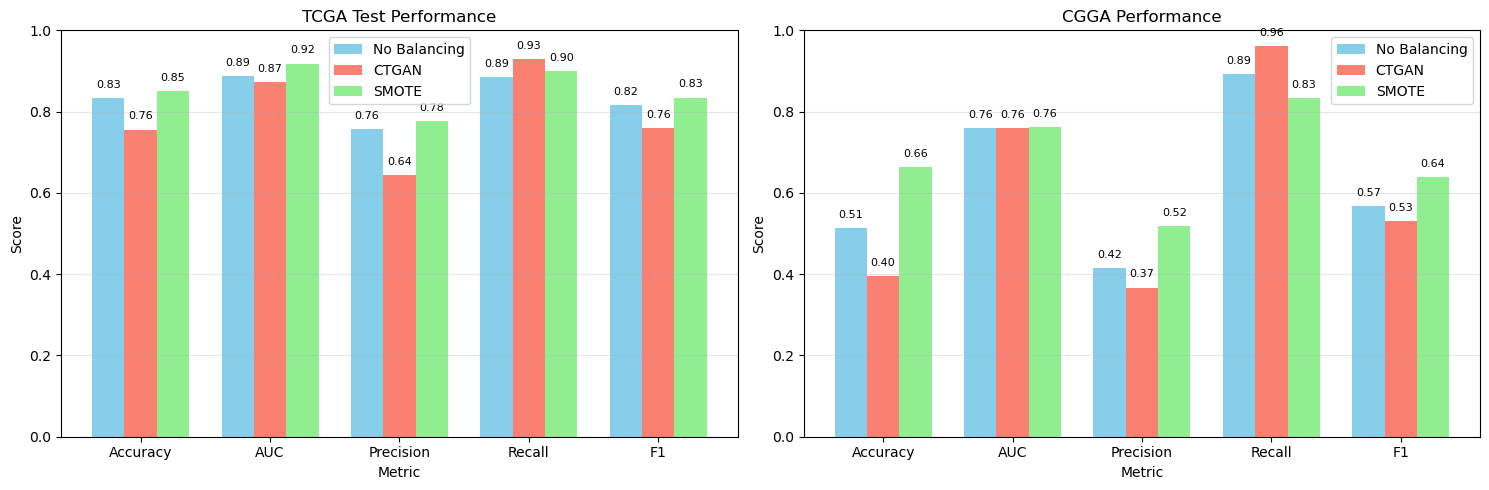

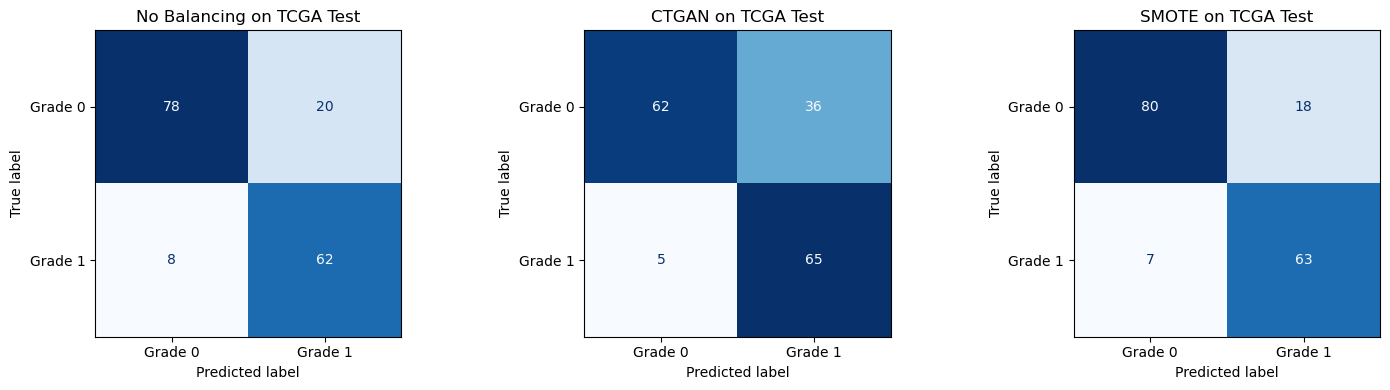

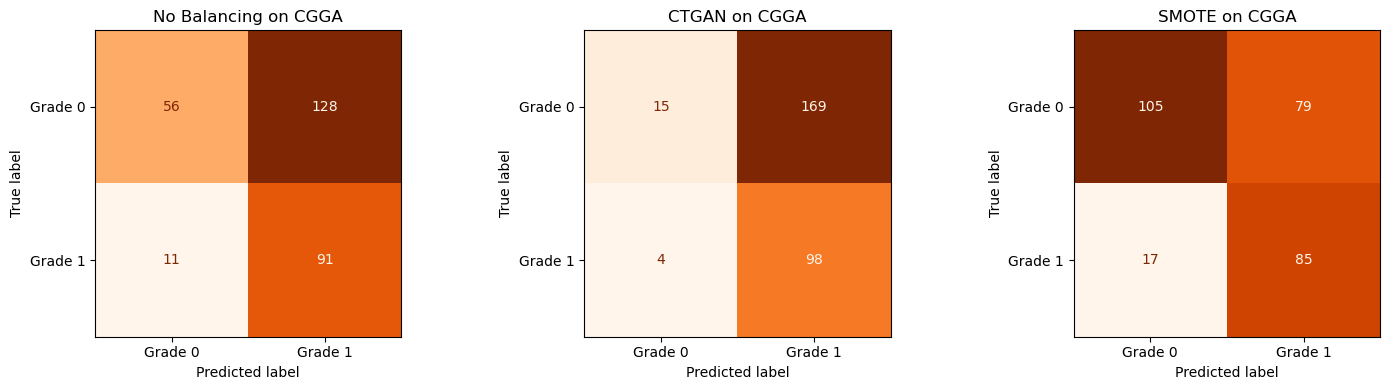


Classification Reports on TCGA Test:

No Balancing:
              precision    recall  f1-score   support

     Grade 0       0.91      0.80      0.85        98
     Grade 1       0.76      0.89      0.82        70

    accuracy                           0.83       168
   macro avg       0.83      0.84      0.83       168
weighted avg       0.84      0.83      0.83       168


CTGAN:
              precision    recall  f1-score   support

     Grade 0       0.93      0.63      0.75        98
     Grade 1       0.64      0.93      0.76        70

    accuracy                           0.76       168
   macro avg       0.78      0.78      0.76       168
weighted avg       0.81      0.76      0.76       168


SMOTE:
              precision    recall  f1-score   support

     Grade 0       0.92      0.82      0.86        98
     Grade 1       0.78      0.90      0.83        70

    accuracy                           0.85       168
   macro avg       0.85      0.86      0.85       168
weigh

In [4]:


# %% [markdown]
# ## 10. Grid Search over Hyperparameters (using CTGAN‑balanced train + val)

# %%
# Define hyperparameter grid
param_grid = {
    'hidden_dim': [16, 32, 64],
    'num_heads': [4, 8],
    'dropout': [0.3, 0.5, 0.7],
    'lr': [0.001, 0.005],
    'weight_decay': [1e-4, 5e-4]
}

# Generate all combinations
keys = param_grid.keys()
values = param_grid.values()
combinations = list(product(*values))

best_score = 0
best_params = None
best_state = None
best_val_aucs = None   # <-- store validation history of best model

print(f"Starting grid search with {len(combinations)} combinations...\n")
for i, combo in enumerate(combinations):
    params = dict(zip(keys, combo))
    print(f"Trial {i+1}/{len(combinations)}: {params}")
    
    val_auc, state, val_aucs = train_model(tcga_train_ctgan_graph, tcga_val_graph, params)
    print(f"  Validation AUC: {val_auc:.4f}\n")
    
    if val_auc > best_score:
        best_score = val_auc
        best_params = params
        best_state = state
        best_val_aucs = val_aucs   # <-- save history

print("="*50)
print("Best hyperparameters found:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Best validation AUC: {best_score:.4f}")
print("="*50)
# %% [markdown]
# ## 11. Build Graphs for All Training Sets (No Balancing, CTGAN, SMOTE)

# %%
tcga_train_no_bal_graph = construct_bipartite_heterograph(train_df).to(device)
tcga_train_ctgan_graph  = construct_bipartite_heterograph(train_ctgan_df).to(device)
tcga_train_smote_graph  = construct_bipartite_heterograph(train_smote_df).to(device)

print("All training graphs built.")

# %% [markdown]
# ## 12. Train All Three Models with Best Hyperparameters

# %%
print("Training on imbalanced data...")
_, state_no_bal, val_aucs_no_bal = train_model(tcga_train_no_bal_graph, tcga_val_graph, best_params)
model_no_bal = HeteroGATv2(**{k: v for k, v in best_params.items() if k in ['hidden_dim', 'num_heads', 'dropout']}, out_dim=2).to(device)
model_no_bal.load_state_dict(state_no_bal)

print("Training on CTGAN-balanced data...")
_, state_ctgan, val_aucs_ctgan = train_model(tcga_train_ctgan_graph, tcga_val_graph, best_params)
model_ctgan = HeteroGATv2(**{k: v for k, v in best_params.items() if k in ['hidden_dim', 'num_heads', 'dropout']}, out_dim=2).to(device)
model_ctgan.load_state_dict(state_ctgan)

print("Training on SMOTE-balanced data...")
_, state_smote, val_aucs_smote = train_model(tcga_train_smote_graph, tcga_val_graph, best_params)
model_smote = HeteroGATv2(**{k: v for k, v in best_params.items() if k in ['hidden_dim', 'num_heads', 'dropout']}, out_dim=2).to(device)
model_smote.load_state_dict(state_smote)

print("All models trained.")

# %% [markdown]
# ## 13. Evaluation Function

# %%
def evaluate_model(model, graph):
    model.eval()
    with torch.no_grad():
        out = model(graph.x_dict, graph.edge_index_dict)
        probs = F.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(dim=1).cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
        
        acc = accuracy_score(labels, preds)
        auc = roc_auc_score(labels, probs[:, 1])
        precision = precision_score(labels, preds, average='binary')
        recall = recall_score(labels, preds, average='binary')
        f1 = f1_score(labels, preds, average='binary')
        
        report = classification_report(labels, preds, output_dict=True, target_names=['Grade 0', 'Grade 1'])
        
    return {
        'accuracy': acc,
        'auc': auc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'report': report,
        'probs': probs,
        'preds': preds,
        'labels': labels
    }

# Evaluate all models
results = []
models_info = [('No Balancing', model_no_bal), ('CTGAN', model_ctgan), ('SMOTE', model_smote)]

for name, model in models_info:
    # TCGA test
    res_test = evaluate_model(model, tcga_test_graph)
    # CGGA
    res_cgga = evaluate_model(model, cgga_graph)
    
    results.append({'Method': name, 'Dataset': 'TCGA Test', 
                    'accuracy': res_test['accuracy'], 'auc': res_test['auc'],
                    'precision': res_test['precision'], 'recall': res_test['recall'], 'f1': res_test['f1']})
    results.append({'Method': name, 'Dataset': 'CGGA', 
                    'accuracy': res_cgga['accuracy'], 'auc': res_cgga['auc'],
                    'precision': res_cgga['precision'], 'recall': res_cgga['recall'], 'f1': res_cgga['f1']})
    
    # Store for plotting
    if name == 'No Balancing':
        probs_test_nb, probs_cgga_nb = res_test['probs'][:,1], res_cgga['probs'][:,1]
        labels_test_nb, labels_cgga_nb = res_test['labels'], res_cgga['labels']
        preds_test_nb, preds_cgga_nb = res_test['preds'], res_cgga['preds']
    elif name == 'CTGAN':
        probs_test_ct, probs_cgga_ct = res_test['probs'][:,1], res_cgga['probs'][:,1]
        labels_test_ct, labels_cgga_ct = res_test['labels'], res_cgga['labels']
        preds_test_ct, preds_cgga_ct = res_test['preds'], res_cgga['preds']
    else:
        probs_test_sm, probs_cgga_sm = res_test['probs'][:,1], res_cgga['probs'][:,1]
        labels_test_sm, labels_cgga_sm = res_test['labels'], res_cgga['labels']
        preds_test_sm, preds_cgga_sm = res_test['preds'], res_cgga['preds']

results_df = pd.DataFrame(results)
print("\n=== Summary Table ===")
print(results_df.to_string(index=False))

# %% [markdown]
# ## 14. Visualizations

# %%
# 14.1 Validation AUC curves during training
plt.figure(figsize=(10,5))
plt.plot(best_val_aucs, label='CTGAN (used for tuning)', color='red', linewidth=2)
plt.plot(val_aucs_no_bal, label='No Balancing', linestyle='--')
plt.plot(val_aucs_ctgan, label='CTGAN')
plt.plot(val_aucs_smote, label='SMOTE')
plt.xlabel('Epoch')
plt.ylabel('Validation AUC')
plt.title('Validation AUC during Training (All Methods)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 14.2 ROC curves on TCGA Test
plt.figure(figsize=(8,6))
fpr_nb, tpr_nb, _ = roc_curve(labels_test_nb, probs_test_nb)
fpr_ct, tpr_ct, _ = roc_curve(labels_test_ct, probs_test_ct)
fpr_sm, tpr_sm, _ = roc_curve(labels_test_sm, probs_test_sm)

# Extract AUC values (using lowercase column names)
auc_nb_test = results_df[(results_df.Method=="No Balancing") & (results_df.Dataset=="TCGA Test")]['auc'].values[0]
auc_ct_test = results_df[(results_df.Method=="CTGAN") & (results_df.Dataset=="TCGA Test")]['auc'].values[0]
auc_sm_test = results_df[(results_df.Method=="SMOTE") & (results_df.Dataset=="TCGA Test")]['auc'].values[0]

plt.plot(fpr_nb, tpr_nb, label=f'No Balancing (AUC = {auc_nb_test:.3f})')
plt.plot(fpr_ct, tpr_ct, label=f'CTGAN (AUC = {auc_ct_test:.3f})')
plt.plot(fpr_sm, tpr_sm, label=f'SMOTE (AUC = {auc_sm_test:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on TCGA Test')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 14.3 ROC curves on CGGA
plt.figure(figsize=(8,6))
fpr_nb, tpr_nb, _ = roc_curve(labels_cgga_nb, probs_cgga_nb)
fpr_ct, tpr_ct, _ = roc_curve(labels_cgga_ct, probs_cgga_ct)
fpr_sm, tpr_sm, _ = roc_curve(labels_cgga_sm, probs_cgga_sm)

auc_nb_cgga = results_df[(results_df.Method=="No Balancing") & (results_df.Dataset=="CGGA")]['auc'].values[0]
auc_ct_cgga = results_df[(results_df.Method=="CTGAN") & (results_df.Dataset=="CGGA")]['auc'].values[0]
auc_sm_cgga = results_df[(results_df.Method=="SMOTE") & (results_df.Dataset=="CGGA")]['auc'].values[0]

plt.plot(fpr_nb, tpr_nb, label=f'No Balancing (AUC = {auc_nb_cgga:.3f})')
plt.plot(fpr_ct, tpr_ct, label=f'CTGAN (AUC = {auc_ct_cgga:.3f})')
plt.plot(fpr_sm, tpr_sm, label=f'SMOTE (AUC = {auc_sm_cgga:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on CGGA')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 14.4 Calibration curves on TCGA Test
plt.figure(figsize=(8,6))
for probs, label in [(probs_test_nb, 'No Balancing'),
                      (probs_test_ct, 'CTGAN'),
                      (probs_test_sm, 'SMOTE')]:
    fraction, mean_pred = calibration_curve(labels_test_nb, probs, n_bins=10)
    plt.plot(mean_pred, fraction, marker='o', label=label)
plt.plot([0,1], [0,1], 'k--', label='Perfect')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curves on TCGA Test')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 14.5 Calibration curves on CGGA
plt.figure(figsize=(8,6))
for probs, label in [(probs_cgga_nb, 'No Balancing'),
                      (probs_cgga_ct, 'CTGAN'),
                      (probs_cgga_sm, 'SMOTE')]:
    fraction, mean_pred = calibration_curve(labels_cgga_nb, probs, n_bins=10)
    plt.plot(mean_pred, fraction, marker='o', label=label)
plt.plot([0,1], [0,1], 'k--', label='Perfect')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curves on CGGA')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 14.6 Bar charts for all metrics (using correct column names)
metrics_display = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1']
metrics_cols = ['accuracy', 'auc', 'precision', 'recall', 'f1']
x = np.arange(len(metrics_display))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15,5))

for ax, dataset in zip(axes, ['TCGA Test', 'CGGA']):
    subset = results_df[results_df.Dataset == dataset]
    nb_vals = [subset[subset.Method == 'No Balancing'][col].values[0] for col in metrics_cols]
    ct_vals = [subset[subset.Method == 'CTGAN'][col].values[0] for col in metrics_cols]
    sm_vals = [subset[subset.Method == 'SMOTE'][col].values[0] for col in metrics_cols]
    
    ax.bar(x - width, nb_vals, width, label='No Balancing', color='skyblue')
    ax.bar(x, ct_vals, width, label='CTGAN', color='salmon')
    ax.bar(x + width, sm_vals, width, label='SMOTE', color='lightgreen')
    
    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')
    ax.set_title(f'{dataset} Performance')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_display)
    ax.set_ylim(0,1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    for i, (nb, ct, sm) in enumerate(zip(nb_vals, ct_vals, sm_vals)):
        ax.text(i - width, nb + 0.02, f'{nb:.2f}', ha='center', va='bottom', fontsize=8)
        ax.text(i, ct + 0.02, f'{ct:.2f}', ha='center', va='bottom', fontsize=8)
        ax.text(i + width, sm + 0.02, f'{sm:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# 14.7 Confusion Matrices for TCGA Test
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, preds, labels) in zip(axes, 
                                      [('No Balancing', preds_test_nb, labels_test_nb),
                                       ('CTGAN', preds_test_ct, labels_test_ct),
                                       ('SMOTE', preds_test_sm, labels_test_sm)]):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Grade 0', 'Grade 1'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} on TCGA Test')
plt.tight_layout()
plt.show()

# 14.8 Confusion Matrices for CGGA
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, preds, labels) in zip(axes, 
                                      [('No Balancing', preds_cgga_nb, labels_cgga_nb),
                                       ('CTGAN', preds_cgga_ct, labels_cgga_ct),
                                       ('SMOTE', preds_cgga_sm, labels_cgga_sm)]):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Grade 0', 'Grade 1'])
    disp.plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(f'{name} on CGGA')
plt.tight_layout()
plt.show()

# 14.9 Print classification reports
print("\nClassification Reports on TCGA Test:")
for name, preds, labels in [('No Balancing', preds_test_nb, labels_test_nb),
                             ('CTGAN', preds_test_ct, labels_test_ct),
                             ('SMOTE', preds_test_sm, labels_test_sm)]:
    print(f"\n{name}:")
    print(classification_report(labels, preds, target_names=['Grade 0', 'Grade 1']))

print("\nClassification Reports on CGGA:")
for name, preds, labels in [('No Balancing', preds_cgga_nb, labels_cgga_nb),
                             ('CTGAN', preds_cgga_ct, labels_cgga_ct),
                             ('SMOTE', preds_cgga_sm, labels_cgga_sm)]:
    print(f"\n{name}:")
    print(classification_report(labels, preds, target_names=['Grade 0', 'Grade 1']))
# %% [markdown]
# ## 15. (Optional) Save Models

# %%
# torch.save(model_no_bal.state_dict(), 'model_no_bal.pth')
# torch.save(model_ctgan.state_dict(), 'model_ctgan.pth')
# torch.save(model_smote.state_dict(), 'model_smote.pth')
# print("Models saved.")